In [8]:
import pandas as pd

df = pd.read_csv("expenses_dataset.csv")
print(df.shape)
df.head(10)

(900, 2)


,description,category
0,Swiggy,Food
1,ATM withdrawal,Other
2,Cab - Bus ticket,Transport
3,society maintenance for the month,Bills
4,Dinner - Domino's Pizza,Food
5,Weekend concert tickets,Entertainment
6,auto fare to the station,Transport
7,lunch at bakery,Food
8,ordered food via street food stall,Food
9,Lunch at Ice cream shop,Food


In [10]:
df["category"].value_counts()

category
Food             152
Transport        152
Bills            152
Other            148
Entertainment    148
Shopping         148
Name: count, dtype: int64

In [12]:
from sklearn.model_selection import train_test_split

X = df["description"]
y = df["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 720, Test size: 180


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Convert text descriptions into numeric vectors
vectorizer = TfidfVectorizer(lowercase=True, stop_words="english")
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train the model
model = MultinomialNB()
model.fit(X_train_vec, y_train)

# Predict on test set
y_pred = model.predict(X_test_vec)

# Evaluate
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

        Bills       1.00      1.00      1.00        30
Entertainment       1.00      1.00      1.00        30
         Food       1.00      1.00      1.00        30
        Other       1.00      1.00      1.00        30
     Shopping       1.00      1.00      1.00        30
    Transport       1.00      1.00      1.00        30

     accuracy                           1.00       180
    macro avg       1.00      1.00      1.00       180
 weighted avg       1.00      1.00      1.00       180



In [14]:
new_examples = [
    "paid for biryani at new restaurant",
    "monthly gym membership fee",
    "recharged fastag for toll",
    "bought a birthday gift for mom",
    "ordered biryani via a food app",
    "electricity board late payment",
    "watched a movie with friends",
    "grabbed a cab to airport",
]

new_vec = vectorizer.transform(new_examples)
predictions = model.predict(new_vec)

for text, pred in zip(new_examples, predictions):
    print(f"{text:45s} -> {pred}")

paid for biryani at new restaurant            -> Food
monthly gym membership fee                    -> Bills
recharged fastag for toll                     -> Transport
bought a birthday gift for mom                -> Shopping
ordered biryani via a food app                -> Food
electricity board late payment                -> Bills
watched a movie with friends                  -> Entertainment
grabbed a cab to airport                      -> Transport


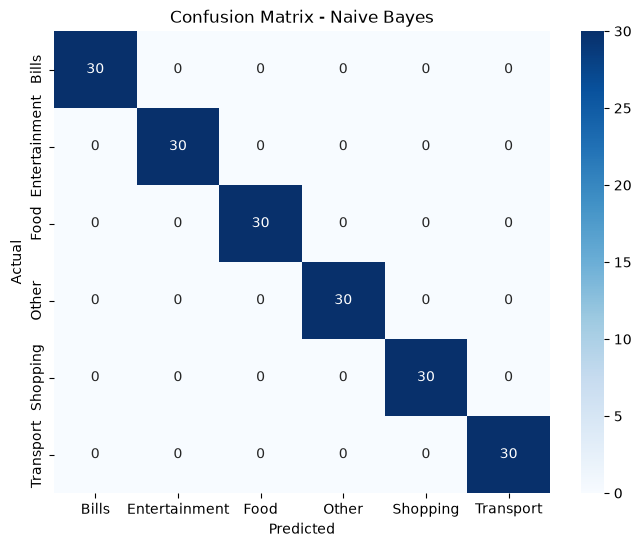

In [15]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

In [16]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_vec, y_train)
lr_pred = lr_model.predict(X_test_vec)

print(classification_report(y_test, lr_pred))

# test on the same tricky examples
lr_new_pred = lr_model.predict(new_vec)
for text, pred in zip(new_examples, lr_new_pred):
    print(f"{text:45s} -> {pred}")

               precision    recall  f1-score   support

        Bills       1.00      1.00      1.00        30
Entertainment       1.00      1.00      1.00        30
         Food       1.00      1.00      1.00        30
        Other       1.00      1.00      1.00        30
     Shopping       1.00      1.00      1.00        30
    Transport       1.00      1.00      1.00        30

     accuracy                           1.00       180
    macro avg       1.00      1.00      1.00       180
 weighted avg       1.00      1.00      1.00       180

paid for biryani at new restaurant            -> Food
monthly gym membership fee                    -> Bills
recharged fastag for toll                     -> Transport
bought a birthday gift for mom                -> Shopping
ordered biryani via a food app                -> Food
electricity board late payment                -> Bills
watched a movie with friends                  -> Entertainment
grabbed a cab to airport                      -> 

In [18]:
from holdout_test import HOLDOUT_EXAMPLES
import numpy as np

texts = [ex[0] for ex in HOLDOUT_EXAMPLES]
true_labels = [ex[1] for ex in HOLDOUT_EXAMPLES]

holdout_vec = vectorizer.transform(texts)
holdout_preds = model.predict(holdout_vec)
holdout_probs = model.predict_proba(holdout_vec)

correct = 0
for text, true_label, pred, probs in zip(texts, true_labels, holdout_preds, holdout_probs):
    confidence = np.max(probs)
    status = "✅" if pred == true_label else "❌"
    if pred == true_label:
        correct += 1
    print(f"{status} {text:50s} true={true_label:15s} pred={pred:15s} confidence={confidence:.2f}")

print(f"\nHonest holdout accuracy: {correct}/{len(HOLDOUT_EXAMPLES)} = {correct/len(HOLDOUT_EXAMPLES)*100:.1f}%")

✅ split the dinner bill with coworkers               true=Food            pred=Food            confidence=0.53
❌ bought some fruit from a vendor                    true=Food            pred=Shopping        confidence=0.60
❌ late night snack run                               true=Food            pred=Entertainment   confidence=0.40
❌ caterer for a small get-together                   true=Food            pred=Bills           confidence=0.17
❌ shared auto to college                             true=Transport       pred=Bills           confidence=0.41
✅ booked a self-drive car for the weekend            true=Transport       pred=Transport       confidence=0.23
❌ bike service at the garage                         true=Transport       pred=Bills           confidence=0.31
✅ air ticket refund minus cancellation fee           true=Transport       pred=Transport       confidence=0.66
✅ new curtains for the bedroom                       true=Shopping        pred=Shopping        confidence=0.41
✅

In [19]:
lr_holdout_preds = lr_model.predict(holdout_vec)
lr_holdout_probs = lr_model.predict_proba(holdout_vec)

correct = 0
for text, true_label, pred, probs in zip(texts, true_labels, lr_holdout_preds, lr_holdout_probs):
    confidence = np.max(probs)
    status = "✅" if pred == true_label else "❌"
    if pred == true_label:
        correct += 1
    print(f"{status} {text:50s} true={true_label:15s} pred={pred:15s} confidence={confidence:.2f}")

print(f"\nLogistic Regression honest holdout accuracy: {correct}/{len(HOLDOUT_EXAMPLES)} = {correct/len(HOLDOUT_EXAMPLES)*100:.1f}%")

✅ split the dinner bill with coworkers               true=Food            pred=Food            confidence=0.48
❌ bought some fruit from a vendor                    true=Food            pred=Shopping        confidence=0.66
❌ late night snack run                               true=Food            pred=Entertainment   confidence=0.43
✅ caterer for a small get-together                   true=Food            pred=Food            confidence=0.21
✅ shared auto to college                             true=Transport       pred=Transport       confidence=0.40
✅ booked a self-drive car for the weekend            true=Transport       pred=Transport       confidence=0.26
❌ bike service at the garage                         true=Transport       pred=Bills           confidence=0.28
✅ air ticket refund minus cancellation fee           true=Transport       pred=Transport       confidence=0.63
✅ new curtains for the bedroom                       true=Shopping        pred=Shopping        confidence=0.37
✅

In [20]:
import joblib

joblib.dump(lr_model, "category_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved!")

Model and vectorizer saved!
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
